# Thesis Analysis: Comparative Prompt Engineering for Student Assessment

This notebook implements a comparative analysis of different LLM prompting strategies (Zero-shot, Few-shot, etc.) to assess student code submissions.

It reuses existing data pipelines from the project while introducing a controlled environment to test different prompt types.

In [42]:
# 1. Imports and API Configuration
import json
import pandas as pd
from typing import List, Dict
from google import genai
from google.genai import types

# Import existing utilities
from utils.constants import GEMINI_API_KEY
from utils.dataset import (
    load_topics_json, 
    load_problem_descriptions, 
    load_joined_datasets, 
    get_best_attempts
)
from lib.llm_batch_analyzer import (
    format_submissions, 
    clean_json_response,
    create_system_instruction as get_final_prompt_instruction # Reuse the complex prompt logic
)

# Initialize Client
client = genai.Client(api_key=GEMINI_API_KEY)

print("Libraries imported and Client initialized.")

Libraries imported and Client initialized.


In [43]:
# 2. Data Loading and Preprocessing

# Configuration
FOCUS_PROBLEMS = [32, 33, 34]
VALIDATION_TARGET_PROBLEMS = [36, 37, 38, 39, 40] 

# Thresholds
EARLY_STRUGGLE_THRESHOLD = 0.9 # Students scoring below this on Focus Prob
FUTURE_STRUGGLE_THRESHOLD = 0.8 # Students scoring below this on Future Prob
TEST_SAMPLE_SIZE = 5 

# Load Data
print("Loading datasets...")
df = load_joined_datasets()

if df is not None:
    # 1. Get best attempts (Use this for "Did they eventually solve it?" check)
    best_df = get_best_attempts(df)
    
    # 2. Identify "Persistent Strugglers"
    
    # A. Students who struggled on Focus Problems
    focus_attempts = best_df[best_df['ProblemID'].isin(FOCUS_PROBLEMS)]
    struggling_early_ids = set(focus_attempts[focus_attempts['Score'] < EARLY_STRUGGLE_THRESHOLD]['SubjectID'])
    
    # B. Students who struggled on Future Problems (Ground Truth = True Risk)
    future_attempts = best_df[best_df['ProblemID'].isin(VALIDATION_TARGET_PROBLEMS)]
    # We calculate their average future performance to see if they generally struggled
    # (Grouping by student to get their average across all future probs they tried)
    future_avgs = future_attempts.groupby('SubjectID')['Score'].mean()
    struggling_future_ids = set(future_avgs[future_avgs < FUTURE_STRUGGLE_THRESHOLD].index)
    
    # C. Intersection: Valid Candidates are those who failed both.
    valid_candidates = list(struggling_early_ids & struggling_future_ids)
    
    print(f"Students with Early Struggle: {len(struggling_early_ids)}")
    print(f"Students with Future Struggle: {len(struggling_future_ids)}")
    print(f"✅ Intersection (Persistent Strugglers): {len(valid_candidates)}")
    
    # 3. Filter DataFrame for Analysis
    # We select the EARLY submissions from these specific students
    candidate_df = best_df[
        (best_df['SubjectID'].isin(valid_candidates)) & 
        (best_df['ProblemID'].isin(FOCUS_PROBLEMS)) & 
        (best_df['Score'] < EARLY_STRUGGLE_THRESHOLD)
    ]
    
    # Sample unique students
    #We use groupby to pick one problem per student to maximize diversity
    test_submissions = candidate_df.sample(frac=1, random_state=42).drop_duplicates(subset=['SubjectID']).head(TEST_SAMPLE_SIZE).to_dict('records')
    
    print(f"\nDataset ready.")
    print(f"Total persistent struggling submissions available: {len(candidate_df)}")
    print(f"Analyzing subset of: {len(test_submissions)} submissions")
    
    # Verification Print
    if len(test_submissions) > 0:
        s_id = test_submissions[0]['SubjectID']
        print(f"\nExample Candidate: {s_id}")
        future_perf = best_df[(best_df['SubjectID'] == s_id) & (best_df['ProblemID'].isin(VALIDATION_TARGET_PROBLEMS))]
        avg_f = future_perf['Score'].mean() if not future_perf.empty else 0
        print(f"  Future Avg Score: {avg_f:.2f} (Should be < {FUTURE_STRUGGLE_THRESHOLD})")

else:
    print("Error: Could not load datasets.")

Loading datasets...
Loading datasets...
Main table: 201,570 rows
CodeState table: 69,627 rows
Subject table: 381 rows

Joining datasets...
Joined dataset: 191,584 rows
Datasets joined successfully.
Columns in the joined dataset:
Index(['Order', 'SubjectID', 'ToolInstances', 'ServerTimestamp',
       'ServerTimezone', 'CourseID', 'CourseSectionID', 'TermID',
       'AssignmentID', 'ProblemID', 'Attempt', 'CodeStateID',
       'IsEventOrderingConsistent', 'EventType', 'Score', 'Compile.Result',
       'CompileMessageType', 'CompileMessageData', 'EventID', 'ParentEventID',
       'SourceLocation', 'Code', 'X-Grade'],
      dtype='object')
Best attempts: 15,375 rows
  Unique students: 372
  Unique problems: 50
Students with Early Struggle: 77
Students with Future Struggle: 22
✅ Intersection (Persistent Strugglers): 12

Dataset ready.
Total persistent struggling submissions available: 23
Analyzing subset of: 5 submissions

Example Candidate: 14374
  Future Avg Score: 0.66 (Should be < 0.8)


In [44]:
# 3. Define Prompt Strategies

# We define functions that return the System Instruction for each strategy.

def get_zero_shot_prompt() -> str:
    """
    Zero-Shot: Direct instruction without examples.
    """
    return """You are a Computer Science instructor. 
Analyze the provided student java code submission.
Identify specific knowledge gaps explaining why the code is incorrect or inefficient.
Predict any future topics the student might struggle with based on these gaps.
Return the result in JSON format with keys: 'knowledge_gaps' (list of strings) and 'future_predictions' (list of strings).
"""

def get_few_shot_prompt() -> str:
    """
    Few-Shot: Instruction + 2 Examples.
    """
    return """You are a CS instructor analyzing student code. Identify knowledge gaps and predict future struggles.

Example 1:
Code:
for(int i=0; i<=str.length(); i++) {
   char c = str.charAt(i); 
}
Analysis:
{
  "knowledge_gaps": ["Off-by-one error (<= length instead of < length) causes IndexOutOfBoundsException"],
  "future_predictions": ["Array traversal", "Nested loops"]
}

Example 2:
Code:
if (str == "hello") { return true; }
Analysis:
{
  "knowledge_gaps": ["String comparison using == instead of .equals()"],
  "future_predictions": ["Object references vs primitives", "Memory model"]
}

Now analyze the user's submission and provide output in the same JSON format.
"""

def get_final_version_prompt() -> str:
    """
    Final Version: Uses the sophisticated prompt from our current codebase
    and enforces strict tagging for validation.
    """
    base_instruction = get_final_prompt_instruction()
    
    # Inject specific strict tagging instructions
    strict_instruction = """
    
    STRICT OUTPUT RULES:
    You must separate quantitative tags from qualitative descriptions.
    
    1. 'knowledge_gaps' must be a list of objects:
       { "category": "STRICT_TAG", "description": "Detailed explanation..." }
       
    2. 'future_predictions' must be a list of objects:
       { "topic_tag": "STRICT_TAG", "risk_explanation": "Detailed explanation..." }
       
    PERMITTED STRICT TAGS for 'category' and 'topic_tag':
    - Loop
    - NestedLoop
    - String
    - Array
    - Logic
    - Condition
    - Method
    - Math
    - Indexing
    - Comparison
    
    Do not invent new tags. Use the closest match.
    """
    
    return base_instruction + strict_instruction

# Dictionary mapping names to prompt generators
PROMPT_STRATEGIES = {
    "Zero-Shot": get_zero_shot_prompt,
    "Few-Shot": get_few_shot_prompt,
    "Final-Curriculum-Aware": get_final_version_prompt
}

print("Prompt strategies defined.")

Prompt strategies defined.


In [45]:
# 4. Configuration and Analysis Engine

# CONTROL PANEL: Select which prompts to run
# Options: "Zero-Shot", "Few-Shot", "Final-Curriculum-Aware"
ACTIVE_PROMPTS = ["Zero-Shot", "Few-Shot", "Final-Curriculum-Aware"] 
# ACTIVE_PROMPTS = ["Final-Curriculum-Aware"] # Use this to save tokens

def run_single_analysis(submission: dict, strategy_name: str, system_instr: str) -> dict:
    """
    Runs analysis for a single submission using a specific prompt strategy.
    """
    # Format the input (User Message)
    # We reuse format_submissions but pass a list of 1 to treat it individually
    formatted_input = format_submissions([submission])
    
    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=formatted_input,
            config=types.GenerateContentConfig(
                system_instruction=system_instr,
                temperature=0.3, # Low temp for consistency
                response_mime_type="application/json"
            )
        )
        
        if response.text:
            cleaned_json = clean_json_response(response.text)
            parsed_result = json.loads(cleaned_json)
            
            return {
                "status": "success",
                "data": parsed_result
            }
            
    except Exception as e:
        return {
            "status": "error",
            "error_msg": str(e)
        }
    
    return {"status": "no_response"}

print(f"Engine configured. Active Prompts: {ACTIVE_PROMPTS}")

Engine configured. Active Prompts: ['Zero-Shot', 'Few-Shot', 'Final-Curriculum-Aware']


In [46]:
# 5. Execution: Run Comparative Analysis

results_data = []

print(f"Starting comparison analysis on {len(test_submissions)} students...")

import time

for index, sub in enumerate(test_submissions):
    student_id = sub['SubjectID']
    problem_id = sub['ProblemID']
    compile_result = sub.get('Compile.Result', 'Unknown')
    
    print(f"\n--- Analyzing Student {student_id} (Problem {problem_id}) [Compile: {compile_result}] ---")
    
    for strategy in ACTIVE_PROMPTS:
        if strategy not in PROMPT_STRATEGIES:
            continue
            
        print(f"  > Running {strategy}...")
        
        # Get the instruction
        instr_func = PROMPT_STRATEGIES[strategy]
        system_instruction = instr_func()
        
        # Call API
        start_time = time.time()
        result = run_single_analysis(sub, strategy, system_instruction)
        duration = time.time() - start_time
        
        # Store Data
        if result['status'] == 'success':
            # Extract high-level data for DataFrame
            raw_data = result['data']
            
            gaps = []
            predictions = []
            
            # PARSING LOGIC based on Strategy
            if strategy == "Final-Curriculum-Aware":
                 # New Structure: List of Objects with 'category'
                 if 'student_analysis' in raw_data and isinstance(raw_data['student_analysis'], list):
                     first_entry = raw_data['student_analysis'][0]
                     
                     # Robust Parsing: Handle both Strict Schema ('category') and Legacy Schema ('gap')
                     # LLM sometimes ignores strict instruction if few-shot examples in base prompt differ
                     g_list = first_entry.get('knowledge_gaps', [])
                     for g in g_list:
                         tag = g.get('category') or g.get('gap') or g.get('missing_concept') or 'Unknown'
                         gaps.append(tag)
                         
                     p_list = first_entry.get('future_predictions', [])
                     for p in p_list:
                         tag = p.get('topic_tag') or p.get('at_risk_topic') or 'Unknown'
                         predictions.append(tag)
            else:
                # Basic prompts (Zero/Few shot) return lists of strings
                # Or sometimes lists of dicts depending on LLM whim, so we handle both
                raw_gaps = raw_data.get('knowledge_gaps', [])
                if raw_gaps and isinstance(raw_gaps[0], dict):
                     gaps = [g.get('gap', str(g)) for g in raw_gaps] 
                else:
                     gaps = raw_gaps
                
                raw_preds = raw_data.get('future_predictions', [])
                if raw_preds and isinstance(raw_preds[0], dict):
                     predictions = [p.get('at_risk_topic', str(p)) for p in raw_preds]
                else:
                     predictions = raw_preds

            results_data.append({
                "Student_ID": student_id,
                "Problem_ID": problem_id,
                "Compile_Status": compile_result,
                "Prompt_Strategy": strategy,
                "Identified_Gaps": str(gaps), 
                "Predictions": str(predictions),
                "Execution_Time_Sec": round(duration, 2),
                "Raw_JSON": json.dumps(raw_data) 
            })
        else:
            print(f"    Error in {strategy}: {result.get('error_msg')}")

print("\nAnalysis Complete.")

Starting comparison analysis on 5 students...

--- Analyzing Student 14374 (Problem 34) [Compile: None] ---
  > Running Zero-Shot...
  > Running Few-Shot...
  > Running Final-Curriculum-Aware...

--- Analyzing Student 14359 (Problem 33) [Compile: None] ---
  > Running Zero-Shot...
  > Running Few-Shot...
  > Running Final-Curriculum-Aware...

--- Analyzing Student 9948 (Problem 32) [Compile: None] ---
  > Running Zero-Shot...
  > Running Few-Shot...
  > Running Final-Curriculum-Aware...

--- Analyzing Student 14414 (Problem 33) [Compile: None] ---
  > Running Zero-Shot...
  > Running Few-Shot...
  > Running Final-Curriculum-Aware...

--- Analyzing Student 14367 (Problem 33) [Compile: None] ---
  > Running Zero-Shot...
  > Running Few-Shot...
  > Running Final-Curriculum-Aware...

Analysis Complete.


In [47]:
# 6. Results Aggregation and DataFrame Display

# Create DataFrame
comparison_df = pd.DataFrame(results_data)

# Display
print("Analysis Results (First 5 rows):")
display(comparison_df.head())

# Optional: Export for Thesis
export_filename = "thesis_prompt_comparison_results.csv"
comparison_df.to_csv(export_filename, index=False)
print(f"\nResults saved to {export_filename}")

Analysis Results (First 5 rows):


Analysis Results (First 5 rows):


,Student_ID,Problem_ID,Compile_Status,Prompt_Strategy,Identified_Gaps,Predictions,Execution_Time_Sec,Raw_JSON
0,14374,34,None,Zero-Shot,['Method Signature and Return Type Mismatch: T...,['Object-Oriented Programming (OOP) Concepts: ...,7.31,"{""knowledge_gaps"": [""Method Signature and Retu..."
1,14374,34,None,Few-Shot,['Method return type mismatch (returning boole...,['Understanding method signatures and return t...,3.24,"{""knowledge_gaps"": [""Method return type mismat..."
2,14374,34,None,Final-Curriculum-Aware,['Misunderstanding of method return types. The...,"['Method', 'Loop', 'String', 'Logic']",8.34,"{""student_analysis"": [{""student_id"": ""14374"", ..."
3,14359,33,None,Zero-Shot,['**Loop Bounds and Off-by-One/Two Errors:** T...,['**Advanced Looping and Iteration:** Problems...,12.77,"{""knowledge_gaps"": [""**Loop Bounds and Off-by-..."
4,14359,33,None,Few-Shot,"['Off-by-two error in loop conditions (e.g., `...",['Array/String traversal and boundary conditio...,8.24,"{""knowledge_gaps"": [""Off-by-two error in loop ..."


Analysis Results (First 5 rows):


,Student_ID,Problem_ID,Compile_Status,Prompt_Strategy,Identified_Gaps,Predictions,Execution_Time_Sec,Raw_JSON
0,14374,34,None,Zero-Shot,['Method Signature and Return Type Mismatch: T...,['Object-Oriented Programming (OOP) Concepts: ...,7.31,"{""knowledge_gaps"": [""Method Signature and Retu..."
1,14374,34,None,Few-Shot,['Method return type mismatch (returning boole...,['Understanding method signatures and return t...,3.24,"{""knowledge_gaps"": [""Method return type mismat..."
2,14374,34,None,Final-Curriculum-Aware,['Misunderstanding of method return types. The...,"['Method', 'Loop', 'String', 'Logic']",8.34,"{""student_analysis"": [{""student_id"": ""14374"", ..."
3,14359,33,None,Zero-Shot,['**Loop Bounds and Off-by-One/Two Errors:** T...,['**Advanced Looping and Iteration:** Problems...,12.77,"{""knowledge_gaps"": [""**Loop Bounds and Off-by-..."
4,14359,33,None,Few-Shot,"['Off-by-two error in loop conditions (e.g., `...",['Array/String traversal and boundary conditio...,8.24,"{""knowledge_gaps"": [""Off-by-two error in loop ..."



Results saved to thesis_prompt_comparison_results.csv


Loading Validation Resources...
Validating predictions for 15 analysis entries...

--- Validation Accuracy by Strategy (Using Best Attempts) ---


Loading Validation Resources...
Validating predictions for 15 analysis entries...

--- Validation Accuracy by Strategy (Using Best Attempts) ---


Prompt_Strategy
Few-Shot                  1.0
Final-Curriculum-Aware    1.0
Zero-Shot                 1.0
Name: Accuracy, dtype: float64


--- Detailed Validation Table ---


Loading Validation Resources...
Validating predictions for 15 analysis entries...

--- Validation Accuracy by Strategy (Using Best Attempts) ---


...

,Student_ID,Prompt_Strategy,Accuracy,Confirmed_Matches,Total_Predictions,Details
0,14374,Zero-Shot,1.0,3,3,[{'prediction': 'Object-Oriented Programming (...
1,14374,Few-Shot,1.0,1,1,[{'prediction': 'Understanding method signatur...
2,14374,Final-Curriculum-Aware,1.0,3,3,"[{'prediction': 'Method', 'result': 'no_data',..."
3,14359,Zero-Shot,1.0,4,4,[{'prediction': '**Advanced Looping and Iterat...
4,14359,Few-Shot,1.0,3,3,[{'prediction': 'Array/String traversal and bo...
5,14359,Final-Curriculum-Aware,1.0,3,3,"[{'prediction': 'Loop', 'result': 'confirmed',..."
6,9948,Zero-Shot,1.0,4,4,[{'prediction': 'Off-by-one Errors: This is a ...
7,9948,Few-Shot,1.0,3,3,[{'prediction': 'StringBuilder for efficient s...
8,9948,Final-Curriculum-Aware,1.0,3,3,"[{'prediction': 'Loop', 'result': 'confirmed',..."
9,14414,Zero-Shot,1.0,4,4,[{'prediction': '**Frequent `IndexOutOfBoundsE...


Loading Validation Resources...
Validating predictions for 15 analysis entries...

--- Validation Accuracy by Strategy (Using Best Attempts) ---


Prompt_Strategy
Few-Shot                  1.0
Final-Curriculum-Aware    1.0
Zero-Shot                 1.0
Name: Accuracy, dtype: float64


--- Detailed Validation Table ---


,Student_ID,Prompt_Strategy,Accuracy,Confirmed_Matches,Total_Predictions,Details
0,14374,Zero-Shot,1.0,3,3,[{'prediction': 'Object-Oriented Programming (...
1,14374,Few-Shot,1.0,1,1,[{'prediction': 'Understanding method signatur...
2,14374,Final-Curriculum-Aware,1.0,3,3,"[{'prediction': 'Method', 'result': 'no_data',..."
3,14359,Zero-Shot,1.0,4,4,[{'prediction': '**Advanced Looping and Iterat...
4,14359,Few-Shot,1.0,3,3,[{'prediction': 'Array/String traversal and bo...
5,14359,Final-Curriculum-Aware,1.0,3,3,"[{'prediction': 'Loop', 'result': 'confirmed',..."
6,9948,Zero-Shot,1.0,4,4,[{'prediction': 'Off-by-one Errors: This is a ...
7,9948,Few-Shot,1.0,3,3,[{'prediction': 'StringBuilder for efficient s...
8,9948,Final-Curriculum-Aware,1.0,3,3,"[{'prediction': 'Loop', 'result': 'confirmed',..."
9,14414,Zero-Shot,1.0,4,4,[{'prediction': '**Frequent `IndexOutOfBoundsE...


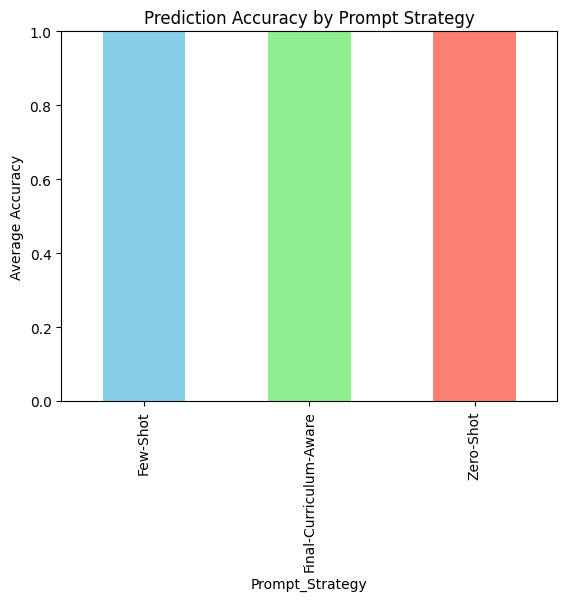

In [48]:
# 7. Validation: Verify LLM Predictions Against Future Performance

import importlib
import lib.prediction_validator
importlib.reload(lib.prediction_validator) # RELOAD to ensure Strict Tag mappings are active
from lib.prediction_validator import validate_predictions, load_problem_topics
import ast

# 1. Load Validation Resources
print("Loading Validation Resources...")
problem_topics_df = load_problem_topics()

# FIX: Use 'best_df' instead of raw 'df'. 
# We want to know if they EVENTUALLY solved the future problems, not if they failed 5 times before succeeding.
validation_dataset = best_df 

# 2. Run Validation Loop
validation_results = []

print(f"Validating predictions for {len(comparison_df)} analysis entries...")

# Ensure ground truth is strictly the target future problems
if 'VALIDATION_TARGET_PROBLEMS' in globals():
    future_data = validation_dataset[validation_dataset['ProblemID'].isin(VALIDATION_TARGET_PROBLEMS)]
else:
    # Fallback only if variable missing
    future_data = validation_dataset[~validation_dataset['ProblemID'].isin(FOCUS_PROBLEMS)]

for idx, row in comparison_df.iterrows():
    student_id = row['Student_ID']
    strategy = row['Prompt_Strategy']
    
    # Parse the stringified lists back to python lists
    try:
        predictions_list = ast.literal_eval(row['Predictions']) 
        
        normalized_preds = []
        for p in predictions_list:
            if isinstance(p, dict):
                normalized_preds.append(p)
            else:
                normalized_preds.append({"at_risk_topic": p})
                
    except Exception as e:
        print(f"Error parsing predictions for row {idx}: {e}")
        continue
        
    # Run Validator
    stats = validate_predictions(
        student_id=student_id,
        predictions=normalized_preds,
        df_all=future_data,
        problem_topics_df=problem_topics_df
    )
    
    validation_results.append({
        "Student_ID": student_id,
        "Prompt_Strategy": strategy,
        "Accuracy": stats['accuracy'],
        "Confirmed_Matches": stats['confirmed_matches'],
        "Total_Predictions": stats['total_predictions'],
        "Details": str(stats['details']) 
    })

# 3. Validation DataFrame
validation_df = pd.DataFrame(validation_results)

# 4. Comparative Metrics
print("\n--- Validation Accuracy by Strategy (Using Best Attempts) ---")
if not validation_df.empty:
    accuracy_summary = validation_df.groupby('Prompt_Strategy')['Accuracy'].mean()
    display(accuracy_summary)

    print("\n--- Detailed Validation Table ---")
    display(validation_df)

    # Optional Plot
    try:
        import matplotlib.pyplot as plt
        accuracy_summary.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'], title='Prediction Accuracy by Prompt Strategy')
        plt.ylabel('Average Accuracy')
        plt.ylim(0, 1.0)
        plt.show()
    except ImportError:
        print("Matplotlib not available for plotting.")
else:
    print("No results to validate.")

In [49]:
# 8. Diagnostics: Why is Accuracy 1.0 everywhere?
# Check if students failed everything in the future.

print(f"--- Diagnostic Check for {len(comparison_df)} Analyzed Students ---")

diag_data = []

# Ensure we use the correct set of validation problems
target_pids = VALIDATION_TARGET_PROBLEMS if 'VALIDATION_TARGET_PROBLEMS' in globals() else [36, 37, 38, 39, 40]

for idx, row in comparison_df.iterrows():
    s_id = row['Student_ID']
    p_id = row['Problem_ID']
    
    # 1. Get Score on Focus Problem (Input)
    focus_row = best_df[(best_df['SubjectID'] == s_id) & (best_df['ProblemID'] == p_id)]
    focus_score = focus_row['Score'].max() if not focus_row.empty else -1
    
    # 2. Get Average Score on Validation Problems (Target)
    future_rows = best_df[(best_df['SubjectID'] == s_id) & (best_df['ProblemID'].isin(target_pids))]
    
    # Calculate stats
    if not future_rows.empty:
        future_avg = future_rows['Score'].mean()
        future_attempts = len(future_rows)
        # Check against Validator Threshold (0.8)
        is_struggling = future_avg < 0.8
    else:
        future_avg = -1
        future_attempts = 0
        is_struggling = "No Data"
        
    diag_data.append({
        "Student": s_id,
        "Focus_Prob": p_id,
        "Focus_Score_Raw": focus_score,
        "Future_Avg_Score": future_avg,
        "Future_Attempts": future_attempts,
        "Validator_Says_Struggling": is_struggling
    })

# Create DataFrame
diag_df = pd.DataFrame(diag_data).drop_duplicates()
display(diag_df)

print(f"\nValidator Threshold involved: avg_score < 0.8")
print(f"Dataset Score Scale: {best_df['Score'].min()} to {best_df['Score'].max()}")

--- Diagnostic Check for 15 Analyzed Students ---


,Student,Focus_Prob,Focus_Score_Raw,Future_Avg_Score,Future_Attempts,Validator_Says_Struggling
0,14374,34,0.000000,0.661538,3,True
3,14359,33,0.200000,0.737382,4,True
6,9948,32,0.090909,0.606316,5,True
9,14414,33,0.400000,0.799336,5,True
12,14367,33,0.666667,0.717472,5,True



Validator Threshold involved: avg_score < 0.8
Dataset Score Scale: 0.0 to 1.0
